# EcoSim Model Rollout

Load a trained prey model and a trained predator model, run a fixed-length simulation, collect population and event metrics, and plot the results.

Edit the model names and `num_steps` in the next cell before running.

In [1]:
from __future__ import annotations

from contextlib import contextmanager
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List
import copy
import sys
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'src').exists() and (candidate / 'pyproject.toml').exists():
            return candidate
    return start


ROOT = find_repo_root(Path.cwd().resolve())
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from config.config import SEED, STEPS_PER_EPISODE
from agents.agent import Prey, Predator
from environment.gym_env import EcoSimEnv
from models.Q_learning import QLearningAgent


# --- Parameters: edit these before running ---
prey_model_name = 'latest'
predator_model_name = 'latest'
num_steps = 500
num_prey = 6
num_predators = 2
agent_type = 'PREY'
map_path = None
frozen_policy_epsilon = 0.05

eval_with_exploration = True
eval_epsilon = 0.05
seed = SEED
results_dir = ROOT / 'src' / 'models' / 'results'
results_dir.mkdir(parents=True, exist_ok=True)

print(f'Notebook root: {ROOT}')
print(f'Results dir: {results_dir}')

Notebook root: C:\Users\alejl\OneDrive\Escritorio\thesis\ecoSim
Results dir: C:\Users\alejl\OneDrive\Escritorio\thesis\ecoSim\src\models\results


In [2]:
def resolve_model_path(model_name: str, species: str) -> Path:
    model_name = str(model_name).strip()
    models_dir = ROOT / 'src' / 'models'
    if model_name.lower() == 'latest':
        candidates = sorted(models_dir.glob(f'trained_{species.lower()}_*.pkl'), key=lambda p: p.stat().st_mtime)
        if candidates:
            return candidates[-1]
        raise FileNotFoundError(f'No {species.lower()} models found in {models_dir}')

    direct_path = Path(model_name)
    if direct_path.exists():
        return direct_path

    if not model_name.endswith('.pkl'):
        model_name = f'{model_name}.pkl'

    exact_path = models_dir / model_name
    if exact_path.exists():
        return exact_path

    candidates = sorted(models_dir.glob(f'trained_{species.lower()}_*.pkl'), key=lambda p: p.stat().st_mtime)
    exact_stem = [path for path in candidates if path.stem == Path(model_name).stem]
    if exact_stem:
        return exact_stem[-1]

    partial = [path for path in candidates if Path(model_name).stem.lower() in path.stem.lower()]
    if partial:
        return partial[-1]

    raise FileNotFoundError(f'Could not resolve {species.lower()} model from {model_name!r}')


@dataclass
class EventTracker:
    prey_births: int = 0
    predator_births: int = 0
    predation_events: int = 0


@contextmanager
def track_ecosim_events(tracker: EventTracker):
    original_prey_reproduce = Prey.reproduce
    original_predator_reproduce = Predator.reproduce
    original_predator_eat = Predator.eat

    def wrapped_prey_reproduce(self, *args, **kwargs):
        offspring = original_prey_reproduce(self, *args, **kwargs)
        if offspring is not None:
            tracker.prey_births += 1
        return offspring

    def wrapped_predator_reproduce(self, *args, **kwargs):
        offspring = original_predator_reproduce(self, *args, **kwargs)
        if offspring is not None:
            tracker.predator_births += 1
        return offspring

    def wrapped_predator_eat(self, *args, **kwargs):
        reward = original_predator_eat(self, *args, **kwargs)
        if reward > 0:
            tracker.predation_events += 1
        return reward

    Prey.reproduce = wrapped_prey_reproduce
    Predator.reproduce = wrapped_predator_reproduce
    Predator.eat = wrapped_predator_eat
    try:
        yield
    finally:
        Prey.reproduce = original_prey_reproduce
        Predator.reproduce = original_predator_reproduce
        Predator.eat = original_predator_eat


def clone_frozen_agent(model_path: Path, agent_id: int = 0) -> QLearningAgent:
    agent = QLearningAgent.load_model_from_file(str(model_path))
    agent.agent_id = agent_id
    agent.epsilon = 0.0
    return agent


def mean_or_zero(values):
    values = list(values)
    return float(np.mean(values)) if values else 0.0

In [3]:
prey_model_path = resolve_model_path(prey_model_name, 'PREY')
predator_model_path = resolve_model_path(predator_model_name, 'PREDATOR')

prey_policy_main = clone_frozen_agent(prey_model_path, agent_id=0)
predator_policy_main = clone_frozen_agent(predator_model_path, agent_id=0)
prey_policy_background = clone_frozen_agent(prey_model_path, agent_id=1)
predator_policy_background = clone_frozen_agent(predator_model_path, agent_id=2)

# Apply evaluation epsilon to cloned policies (controls small stochasticity during evaluation)
prey_policy_main.epsilon = float(eval_epsilon)
predator_policy_main.epsilon = float(eval_epsilon)
prey_policy_background.epsilon = float(eval_epsilon)
predator_policy_background.epsilon = float(eval_epsilon)

if agent_type.upper() == 'PREY':
    main_policy = prey_policy_main
    opponent_policy = predator_policy_background
    same_species_policy = prey_policy_background
    opponent_label = 'PREDATOR'
    same_species_label = 'PREY'
else:
    main_policy = predator_policy_main
    opponent_policy = prey_policy_background
    same_species_policy = predator_policy_background
    opponent_label = 'PREY'
    same_species_label = 'PREDATOR'

print(f'Main model: {main_policy.__class__.__name__} from {prey_model_path.name if agent_type.upper() == "PREY" else predator_model_path.name}')
print(f'Opponent background model: {opponent_label}')
print(f'Same-species background model: {same_species_label}')

tracker = EventTracker()
records = []


def build_snapshot(env, step_index: int, reward: float, cumulative_reward: float, tracker: EventTracker, previous_alive_ids: set[int], known_agent_types: Dict[int, str]):
    all_agents = [env.agent] + list(env.other_agents)
    alive_agents = [agent for agent in all_agents if agent.is_alive()]
    prey_agents = [agent for agent in alive_agents if agent.agent_type == 'PREY']
    predator_agents = [agent for agent in alive_agents if agent.agent_type == 'PREDATOR']

    current_alive_ids = {agent.agent_id for agent in alive_agents}
    for agent in all_agents:
        known_agent_types.setdefault(agent.agent_id, agent.agent_type)

    deaths = previous_alive_ids - current_alive_ids
    prey_deaths = sum(1 for agent_id in deaths if known_agent_types.get(agent_id) == 'PREY')
    predator_deaths = sum(1 for agent_id in deaths if known_agent_types.get(agent_id) == 'PREDATOR')

    main_agent = env.agent
    return {
        'step': step_index,
        'reward': reward,
        'cumulative_reward': cumulative_reward,
        'main_agent_energy': float(main_agent.energy),
        'main_agent_thirst': float(main_agent.thirst),
        'main_agent_can_reproduce': int(main_agent.get_observation(env.env)[6]),
        'main_agent_water_nearby': int(main_agent.get_observation(env.env)[7]),
        'prey_population': len(prey_agents),
        'predator_population': len(predator_agents),
        'total_alive': len(alive_agents),
        'avg_prey_energy': mean_or_zero(agent.energy for agent in prey_agents),
        'avg_predator_energy': mean_or_zero(agent.energy for agent in predator_agents),
        'min_prey_energy': float(min((agent.energy for agent in prey_agents), default=0.0)),
        'max_prey_energy': float(max((agent.energy for agent in prey_agents), default=0.0)),
        'min_predator_energy': float(min((agent.energy for agent in predator_agents), default=0.0)),
        'max_predator_energy': float(max((agent.energy for agent in predator_agents), default=0.0)),
        'cumulative_prey_births': tracker.prey_births,
        'cumulative_predator_births': tracker.predator_births,
        'cumulative_predation_events': tracker.predation_events,
        'cumulative_prey_deaths': build_snapshot.cumulative_prey_deaths + prey_deaths,
        'cumulative_predator_deaths': build_snapshot.cumulative_predator_deaths + predator_deaths,
        'cumulative_prey_reward': float(sum(agent.episode_reward for agent in all_agents if agent.agent_type == 'PREY')),
        'cumulative_predator_reward': float(sum(agent.episode_reward for agent in all_agents if agent.agent_type == 'PREDATOR')),
    }, current_alive_ids


build_snapshot.cumulative_prey_deaths = 0
build_snapshot.cumulative_predator_deaths = 0

Main model: QLearningAgent from trained_prey_17_protocol2_cycle7.pkl
Opponent background model: PREDATOR
Same-species background model: PREY


In [4]:
with track_ecosim_events(tracker):
    env = EcoSimEnv(
        agent_id=0,
        num_prey=num_prey,
        num_predators=num_predators,
        agent_type=agent_type,
        map_path=map_path,
        memory=False,
        opponent_agent=opponent_policy,
        opponent_type=opponent_label,
        same_species_agent=same_species_policy,
        same_species_type=same_species_label,
        frozen_policy_epsilon=frozen_policy_epsilon,
    )

    observation = env.reset(seed=seed)
    previous_alive_ids = {agent.agent_id for agent in [env.agent] + list(env.other_agents) if agent.is_alive()}
    known_agent_types = {agent.agent_id: agent.agent_type for agent in [env.agent] + list(env.other_agents)}
    cumulative_reward = 0.0

    for step_index in range(1, num_steps + 1):
        main_state = main_policy.discretize_state(observation)
        # Use eval_with_exploration flag: if True, allow small-epsilon stochastic actions during rollout
        action = main_policy.select_action(main_state, training=eval_with_exploration)
        observation, reward, done, info = env.step(action)
        cumulative_reward += reward

        snapshot, previous_alive_ids = build_snapshot(
            env,
            step_index,
            reward,
            cumulative_reward,
            tracker,
            previous_alive_ids,
            known_agent_types,
        )
        records.append(snapshot)

        if done:
            print(f'Simulation ended early at step {step_index}.')
            break

results_df = pd.DataFrame(records)
results_path = results_dir / f'rollout_{prey_model_path.stem}__{predator_model_path.stem}_{len(results_df)}steps.csv'
results_df.to_csv(results_path, index=False)
print(f'Saved rollout data to {results_path}')
results_df.head()

✓ Using custom opponent agent for PREDATOR
✓ Using frozen same-species policy for PREY (eps=0.050)
Simulation ended early at step 500.
Saved rollout data to C:\Users\alejl\OneDrive\Escritorio\thesis\ecoSim\src\models\results\rollout_trained_prey_17_protocol2_cycle7__trained_predator_17_protocol2_cycle7_500steps.csv


,step,reward,cumulative_reward,main_agent_energy,main_agent_thirst,main_agent_can_reproduce,main_agent_water_nearby,prey_population,predator_population,total_alive,...,max_prey_energy,min_predator_energy,max_predator_energy,cumulative_prey_births,cumulative_predator_births,cumulative_predation_events,cumulative_prey_deaths,cumulative_predator_deaths,cumulative_prey_reward,cumulative_predator_reward
0,1,39.98,39.98,100.00,99.5,0,1,7,2,9,...,100.00,84.55,84.55,0,0,0,0,0,239.87,-0.02
1,2,-0.01,39.97,99.55,99.0,0,1,7,2,9,...,100.00,84.10,84.10,0,0,0,0,0,279.79,-0.04
2,3,-0.01,39.96,99.10,98.5,0,1,7,2,9,...,99.55,83.65,83.65,0,0,0,0,0,279.72,-0.06
3,4,-0.01,39.95,98.65,98.0,0,1,7,2,9,...,99.10,83.20,83.20,0,0,0,0,0,279.65,-0.08
4,5,-0.01,39.94,98.20,97.5,0,1,7,2,9,...,98.65,82.75,82.75,0,0,0,0,0,279.58,-0.10


In [5]:
summary = {
    'steps_ran': int(len(results_df)),
    'final_prey_population': int(results_df['prey_population'].iloc[-1]) if not results_df.empty else 0,
    'final_predator_population': int(results_df['predator_population'].iloc[-1]) if not results_df.empty else 0,
    'peak_prey_population': int(results_df['prey_population'].max()) if not results_df.empty else 0,
    'peak_predator_population': int(results_df['predator_population'].max()) if not results_df.empty else 0,
    'cumulative_prey_births': int(results_df['cumulative_prey_births'].iloc[-1]) if not results_df.empty else 0,
    'cumulative_predator_births': int(results_df['cumulative_predator_births'].iloc[-1]) if not results_df.empty else 0,
    'cumulative_predation_events': int(results_df['cumulative_predation_events'].iloc[-1]) if not results_df.empty else 0,
    'cumulative_prey_deaths': int(results_df['cumulative_prey_deaths'].iloc[-1]) if not results_df.empty else 0,
    'cumulative_predator_deaths': int(results_df['cumulative_predator_deaths'].iloc[-1]) if not results_df.empty else 0,
    'final_cumulative_reward': float(results_df['cumulative_reward'].iloc[-1]) if not results_df.empty else 0.0,
}

pd.Series(summary, name='summary')

steps_ran                      500.00
final_prey_population          226.00
final_predator_population        0.00
peak_prey_population           226.00
peak_predator_population         2.00
cumulative_prey_births         219.00
cumulative_predator_births       0.00
cumulative_predation_events      0.00
cumulative_prey_deaths           0.00
cumulative_predator_deaths       0.00
final_cumulative_reward        401.27
Name: summary, dtype: float64

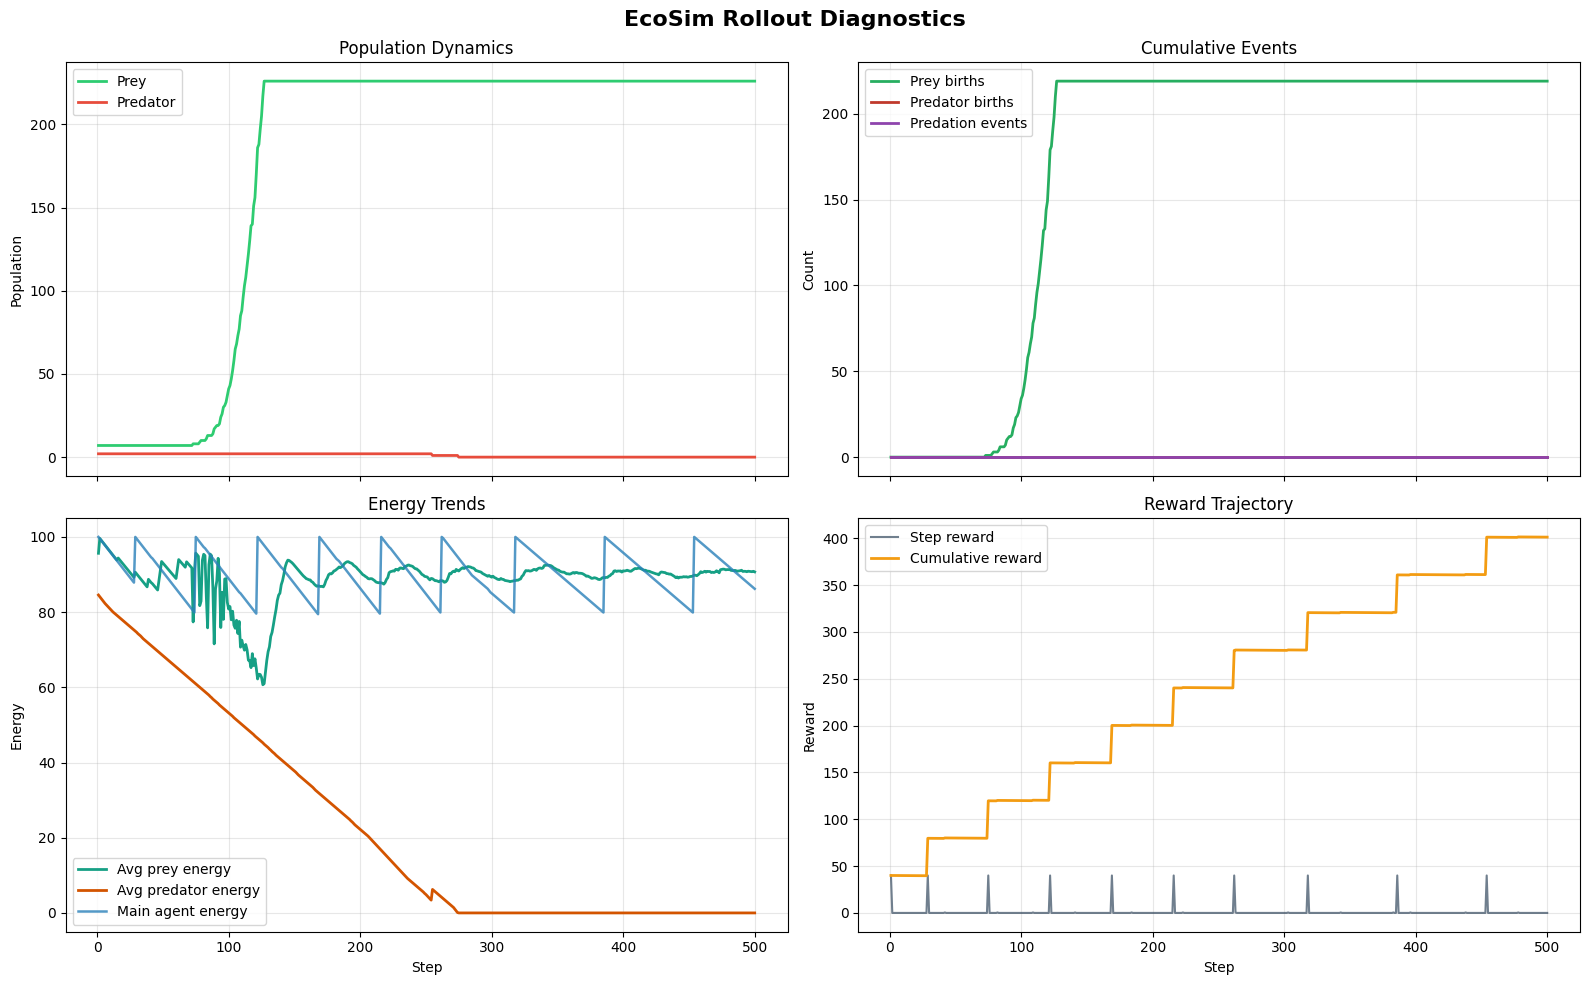

In [7]:
if not results_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
    fig.suptitle('EcoSim Rollout Diagnostics', fontsize=16, fontweight='bold')

    ax = axes[0, 0]
    ax.plot(results_df['step'], results_df['prey_population'], label='Prey', color='#2ecc71', linewidth=2)
    ax.plot(results_df['step'], results_df['predator_population'], label='Predator', color='#e74c3c', linewidth=2)
    ax.set_ylabel('Population')
    ax.set_title('Population Dynamics')
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[0, 1]
    ax.plot(results_df['step'], results_df['cumulative_prey_births'], label='Prey births', color='#27ae60', linewidth=2)
    ax.plot(results_df['step'], results_df['cumulative_predator_births'], label='Predator births', color='#c0392b', linewidth=2)
    ax.plot(results_df['step'], results_df['cumulative_predation_events'], label='Predation events', color='#8e44ad', linewidth=2)
    ax.set_title('Cumulative Events')
    ax.set_ylabel('Count')
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[1, 0]
    ax.plot(results_df['step'], results_df['avg_prey_energy'], label='Avg prey energy', color='#16a085', linewidth=2)
    ax.plot(results_df['step'], results_df['avg_predator_energy'], label='Avg predator energy', color='#d35400', linewidth=2)
    ax.plot(results_df['step'], results_df['main_agent_energy'], label='Main agent energy', color='#2980b9', linewidth=1.8, alpha=0.8)
    ax.set_xlabel('Step')
    ax.set_ylabel('Energy')
    ax.set_title('Energy Trends')
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[1, 1]
    ax.plot(results_df['step'], results_df['reward'], label='Step reward', color='#34495e', linewidth=1.5, alpha=0.7)
    ax.plot(results_df['step'], results_df['cumulative_reward'], label='Cumulative reward', color='#f39c12', linewidth=2)
    ax.set_xlabel('Step')
    ax.set_ylabel('Reward')
    ax.set_title('Reward Trajectory')
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print('No results to plot.')

In [8]:
from pathlib import Path

csv_path = ROOT / 'src' / 'models' / 'results' / 'protocol_alternating_17.csv'


def analyze_protocol_csv(csv_path: Path) -> pd.DataFrame:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f'CSV not found: {csv_path}')

    df = pd.read_csv(csv_path)
    required_columns = {
        'cycle', 'phase', 'agent_type', 'episode', 'reward', 'steps', 'eval_reward',
        'prey_population', 'predator_population', 'avg_prey_energy', 'avg_predator_energy'
    }
    missing_columns = required_columns.difference(df.columns)
    if missing_columns:
        raise ValueError(f'Missing columns in {csv_path.name}: {sorted(missing_columns)}')

    df = df.copy()
    df['cycle'] = pd.to_numeric(df['cycle'], errors='coerce').astype('Int64')
    df['episode'] = pd.to_numeric(df['episode'], errors='coerce').astype('Int64')
    numeric_columns = [
        'reward', 'steps', 'eval_reward', 'prey_population', 'predator_population',
        'avg_prey_energy', 'avg_predator_energy'
    ]
    for column in numeric_columns:
        df[column] = pd.to_numeric(df[column], errors='coerce')

    def summarize_subset(subset_df: pd.DataFrame, species_label: str) -> pd.Series:
        if subset_df.empty:
            return pd.Series({
                'species': species_label,
                'episodes': 0,
                'avg_reward': 0.0,
                'avg_eval_reward': 0.0,
                'avg_steps': 0.0,
                'min_steps': 0,
                'max_steps': 0,
                'prey_population_mean': 0.0,
                'prey_population_peak': 0,
                'predator_population_mean': 0.0,
                'predator_population_peak': 0,
                'avg_prey_energy_mean': 0.0,
                'avg_predator_energy_mean': 0.0,
                'active_population_steps': 0,
                'predation_proxy_steps': 0,
                'best_reward_episode': 0,
                'best_reward_agent': species_label,
                'best_reward_phase': '',
                'best_reward': 0.0,
                'best_eval_episode': 0,
                'best_eval_agent': species_label,
                'best_eval_phase': '',
                'best_eval_reward': 0.0,
                'worst_reward_episode': 0,
                'worst_reward_agent': species_label,
                'worst_reward_phase': '',
                'worst_reward': 0.0,
            })

        best_reward_idx = subset_df['reward'].idxmax()
        best_eval_idx = subset_df['eval_reward'].idxmax()
        worst_reward_idx = subset_df['reward'].idxmin()

        best_reward_row = subset_df.loc[best_reward_idx]
        best_eval_row = subset_df.loc[best_eval_idx]
        worst_reward_row = subset_df.loc[worst_reward_idx]

        population_column = 'prey_population' if species_label == 'PREY' else 'predator_population'
        energy_column = 'avg_prey_energy' if species_label == 'PREY' else 'avg_predator_energy'
        active_population_steps = int((subset_df[population_column] > 0).sum())
        predation_proxy_steps = int((subset_df['avg_predator_energy'] > 0).sum()) if species_label == 'PREDATOR' else int((subset_df['avg_prey_energy'] > 0).sum())

        return pd.Series({
            'species': species_label,
            'episodes': int(subset_df['episode'].nunique()),
            'avg_reward': float(subset_df['reward'].mean()),
            'avg_eval_reward': float(subset_df['eval_reward'].mean()),
            'avg_steps': float(subset_df['steps'].mean()),
            'min_steps': int(subset_df['steps'].min()),
            'max_steps': int(subset_df['steps'].max()),
            'prey_population_mean': float(subset_df['prey_population'].mean()),
            'prey_population_peak': int(subset_df['prey_population'].max()),
            'predator_population_mean': float(subset_df['predator_population'].mean()),
            'predator_population_peak': int(subset_df['predator_population'].max()),
            'avg_prey_energy_mean': float(subset_df['avg_prey_energy'].mean()),
            'avg_predator_energy_mean': float(subset_df['avg_predator_energy'].mean()),
            'active_population_steps': active_population_steps,
            'predation_proxy_steps': predation_proxy_steps,
            'best_reward_episode': int(best_reward_row['episode']),
            'best_reward_agent': str(best_reward_row['agent_type']),
            'best_reward_phase': str(best_reward_row['phase']),
            'best_reward': float(best_reward_row['reward']),
            'best_eval_episode': int(best_eval_row['episode']),
            'best_eval_agent': str(best_eval_row['agent_type']),
            'best_eval_phase': str(best_eval_row['phase']),
            'best_eval_reward': float(best_eval_row['eval_reward']),
            'worst_reward_episode': int(worst_reward_row['episode']),
            'worst_reward_agent': str(worst_reward_row['agent_type']),
            'worst_reward_phase': str(worst_reward_row['phase']),
            'worst_reward': float(worst_reward_row['reward']),
        })

    summary_rows = []
    for cycle, cycle_df in df.groupby('cycle', dropna=False):
        cycle_value = int(cycle)
        prey_subset = cycle_df[cycle_df['agent_type'].str.upper() == 'PREY']
        predator_subset = cycle_df[cycle_df['agent_type'].str.upper() == 'PREDATOR']

        prey_summary = summarize_subset(prey_subset, 'PREY').to_dict()
        predator_summary = summarize_subset(predator_subset, 'PREDATOR').to_dict()

        prey_summary['cycle'] = cycle_value
        predator_summary['cycle'] = cycle_value
        summary_rows.extend([prey_summary, predator_summary])

    cycle_summary = pd.DataFrame(summary_rows)
    cycle_summary = cycle_summary[
        [
            'cycle', 'species', 'episodes', 'avg_reward', 'avg_eval_reward', 'avg_steps', 'min_steps', 'max_steps',
            'prey_population_mean', 'prey_population_peak', 'predator_population_mean', 'predator_population_peak',
            'avg_prey_energy_mean', 'avg_predator_energy_mean', 'active_population_steps', 'predation_proxy_steps',
            'best_reward_episode', 'best_reward_agent', 'best_reward_phase', 'best_reward',
            'best_eval_episode', 'best_eval_agent', 'best_eval_phase', 'best_eval_reward',
            'worst_reward_episode', 'worst_reward_agent', 'worst_reward_phase', 'worst_reward'
        ]
    ]
    return cycle_summary.sort_values(['cycle', 'species']).reset_index(drop=True)


protocol_summary = analyze_protocol_csv(csv_path)
print(f'Analyzed {protocol_summary["cycle"].nunique()} cycles and {len(protocol_summary)} cycle-species rows from {csv_path.name}')
protocol_summary

Analyzed 10 cycles and 20 cycle-species rows from protocol_alternating_17.csv


,cycle,species,episodes,avg_reward,avg_eval_reward,avg_steps,min_steps,max_steps,prey_population_mean,prey_population_peak,...,best_reward_phase,best_reward,best_eval_episode,best_eval_agent,best_eval_phase,best_eval_reward,worst_reward_episode,worst_reward_agent,worst_reward_phase,worst_reward
0,1,PREDATOR,350,57.587838,112.537083,238.200000,204,250,93.340000,225,...,B,273.787500,1,PREDATOR,B,112.537083,5,PREDATOR,B,-5.56
1,1,PREY,350,5030.334286,223.392000,244.857143,7,250,44.302857,226,...,A,8480.500000,1,PREY,A,223.392000,253,PREY,A,-9.57
2,2,PREDATOR,350,62.669367,125.235500,237.082857,206,250,84.274286,225,...,B,1238.525000,1,PREDATOR,B,125.235500,10,PREDATOR,B,-5.11
3,2,PREY,350,5151.320486,172.500000,247.665714,1,250,110.594286,226,...,A,8481.500000,1,PREY,A,172.500000,22,PREY,A,-10.01
4,3,PREDATOR,350,57.376943,124.201667,237.757143,206,250,91.328571,225,...,B,620.222500,1,PREDATOR,B,124.201667,2,PREDATOR,B,-4.58
5,3,PREY,350,5177.118429,180.500000,248.585714,3,250,99.920000,226,...,A,8361.000000,1,PREY,A,180.500000,127,PREY,A,-10.03
6,4,PREDATOR,350,58.668486,122.500000,237.531429,207,250,103.128571,225,...,B,860.559167,1,PREDATOR,B,122.500000,6,PREDATOR,B,-4.60
7,4,PREY,350,5160.469400,184.500000,248.631429,3,250,103.165714,226,...,A,8442.000000,1,PREY,A,184.500000,175,PREY,A,29.97
8,5,PREDATOR,350,57.916126,122.500000,238.102857,206,250,12.220000,225,...,B,610.525000,1,PREDATOR,B,122.500000,1,PREDATOR,B,-4.06
9,5,PREY,350,5162.246114,280.500000,248.245714,1,250,121.497143,226,...,A,8400.500000,1,PREY,A,280.500000,92,PREY,A,-10.01
